In [ ]:
#RQ3: Are there statistically significant effects for streamer gender, age, and genre on the expression of sentiment 
#(positive or negative) in emote-containing messages?
# Logistic Regression per emote, with streamer level clustered SE

In [6]:
import numpy as np
import pandas as pd
import itertools
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
import io

In [7]:
df = pd.read_csv("/Users/inecuypers/Documents/DTA thesis/finals/df_sentiment_emotion_final.csv", index_col=0)
df.head(1)

,id,streamer,message,emotes,gender,age,genre,unique_emotes,total_emotes,sentiment,...,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,6b9fd713-82dc-4f76-90b3-a7d2f006e1ac,annacramling,Gg CoolCat,CoolCat,female,genz,nongaming,1,1,2,...,False,False,False,True,False,True,False,False,False,True


In [8]:
# recode sentiment to binary 0/1
df_rq3 = df.copy()

df["sentiment_bin"] = df["sentiment"].map({
    0: 0,
    2: 1
})
#print(df["sentiment_bin"])

                           Logit Regression Results                           
Dep. Variable:          sentiment_bin   No. Observations:                 9600
Model:                          Logit   Df Residuals:                     9592
Method:                           MLE   Df Model:                            7
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                 0.01370
Time:                        17:04:52   Log-Likelihood:                -3227.0
converged:                       True   LL-Null:                       -3271.8
Covariance Type:              cluster   LLR p-value:                 1.459e-16
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                                               2.5123      0.140     17.969      0.000       2.238       2.786
gender[T

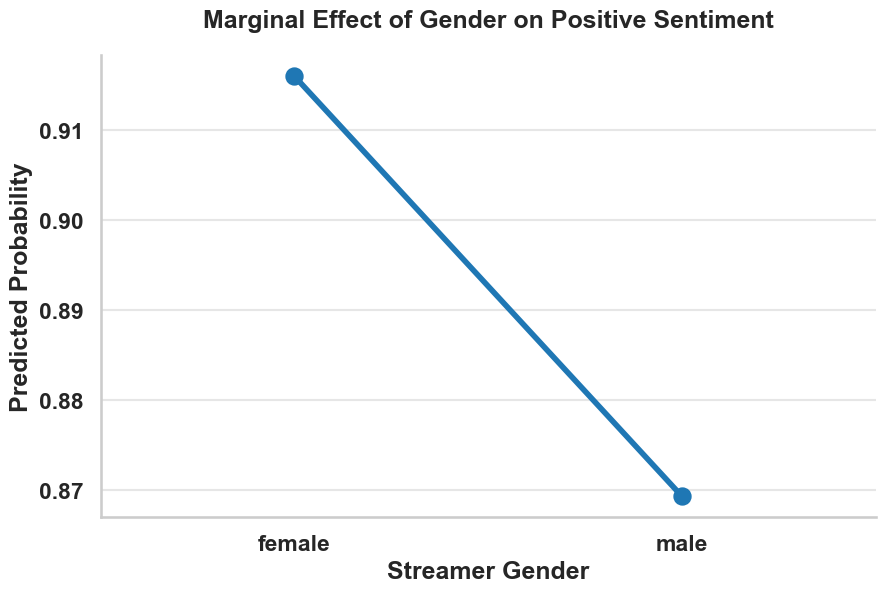

Completed.


In [10]:
model = smf.logit("sentiment_bin ~ gender * age * genre", data=df)

results = model.fit(cov_type='cluster', cov_kwds={'groups': df['streamer']}, disp=0)

print(results.summary())
        
# --- A. Save LaTeX Table ---
html_table = results.summary().tables[1].as_html()
res_df = pd.read_html(io.StringIO(html_table), header=0, index_col=0)[0]
    
res_df.to_latex(f"table_sentiment_logit.tex", escape=False)
    
# --- B. Create Marginal Effects Plot ---
combos = df[['gender', 'genre', 'age']].drop_duplicates()
combos['prob'] = results.predict(combos)
    
# Aggregate (mean) across Age to isolate Gender x Genre
plot_data = combos.groupby('gender')['prob'].mean().reset_index()

# 2. Plotting for "Buttony" Aesthetic
plt.figure(figsize=(10, 6))
sns.set_context("talk") # Makes labels larger/bolder
sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})

# Using a pointplot to show the interaction lines clearly
g = sns.pointplot(
    data=plot_data, 
    x="gender", 
    y="prob",
)

# 3. Clean up the "UI" of the plot
plt.title("Marginal Effect of Gender on Positive Sentiment", pad=20, fontweight='bold')
plt.xlabel("Streamer Gender", fontweight='bold')
plt.ylabel(f"Predicted Probability", fontweight='bold')

ax = plt.gca()
    
for label in ax.get_xticklabels():
    label.set_fontweight("bold")
    
for label in ax.get_yticklabels():
    label.set_fontweight("bold")
    
# Remove top and right spines for a modern look
sns.despine()
    
plt.savefig(f"plot_sentiment_gender.png", dpi=300, bbox_inches='tight')
plt.show()

print("Completed.")